In [1]:
import ee
import geemap
import matplotlib.pyplot as plt

#Initialize earth Engine 
ee.Initialize(project="drishtisar")
print("Google Earth Engine initialized successfully!")

c:\Users\LENOVO\anaconda3\envs\drishtisar\lib\site-packages\google\api_core\_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Google Earth Engine initialized successfully!


In [11]:
# Cell 2: Define Area of Interest (AOI) - Flexible version

# Option 1: Pre-defined areas (easy to switch)
areas = {
    # [min_lon, min_lat, max_lon, max_lat] #We can get the coorrdinates by using bbox finder 
    "Assam_Flood": [92.8, 26.0, 93.2, 26.4],
    "North_Bihar": [85.5, 25.8, 87.0, 26.5],
    "Kerala": [76.0, 9.5, 77.0, 10.5],
    "Uttarakhand": [78.5, 29.8, 79.5, 30.5],
    "Delhi_NCR": [76.8, 28.4, 77.5, 28.9],
    "Uttarakhand_Joshimath": [79.35, 30.35, 79.65, 30.60]
}

selected_area = "Uttarakhand_Joshimath"   # Change this string to test other areas

aoi_coords = areas[selected_area]
aoi = ee.Geometry.Rectangle(aoi_coords)

# Center point for map (average of coordinates)
center_lon = (aoi_coords[0] + aoi_coords[2]) / 2
center_lat = (aoi_coords[1] + aoi_coords[3]) / 2
center = [center_lat, center_lon]

print(f"Selected AOI: {selected_area}")
print(f"Coordinates: {aoi_coords}")

Selected AOI: Uttarakhand_Joshimath
Coordinates: [79.35, 30.35, 79.65, 30.6]


In [12]:
# Cell 3: Load Sentinel-2 (Optical - Colour) - BETTER: Less cloudy (dry season)
# === BETTER SENTINEL-2 EXPORT (Less cloudy) ===
# Use dry season / post-monsoon for Uttarakhand
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2024-11-01', '2025-03-31')        # Changed to drier months (post-monsoon)
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))   # Much stricter cloud filter
      .sort('CLOUDY_PIXEL_PERCENTAGE')
      .first())

# True colour visualization (RGB)
vis_s2 = {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000}

print("Sentinel-2 image selected")

Sentinel-2 image selected


In [13]:
# Cell 4: Load Sentinel-1 (SAR - All weather)
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD') #Ground range detected image collection
      .filterBounds(aoi)
      .filterDate('2024-11-01', '2025-03-31') #Same date range as s2 for better comparison
      .filter(ee.Filter.eq('instrumentMode', 'IW')) #Keeps only images collected in Interferometric Wide swath mode(Primary mode for s1)
      .filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING'))  # or DESCENDING #in s1 it tells which way the satellite was moving when it collected that scene (ASC- South to north), DESC - N to S
      .select(['VV', 'VH']) #VV is vertical transmit, vertical receive #VH is vertical transmit, horizontal receive 
      .first()) # We take the first image that matches our criteria (you can also do median or mosaic for multiple images)

#Polarization is VH and VV which is how radar signals are transmitted and received 

# Visualization for SAR (VV polarization - good for water/flood)
vis_s1 = {'bands': 'VV', 'min': -25, 'max': 0}

print("Sentinel-1 SAR image loaded")

Sentinel-1 SAR image loaded


In [14]:
# Cell 5: Side-by-side comparison view

Map = geemap.Map(center=center, zoom=11)

# Convert the Earth Engine images into tile layers for the split map
left_layer = geemap.ee_tile_layer(s2, vis_s2, 'Sentinel-2 (Optical)', shown=True, opacity=1.0)
right_layer = geemap.ee_tile_layer(s1, vis_s1, 'Sentinel-1 (SAR)', shown=True, opacity=0.85)

# Show Sentinel-2 on the left and Sentinel-1 on the right
Map.split_map(
    left_layer=left_layer,
    right_layer=right_layer,
    left_label='Sentinel-2 (Optical)',
    right_label='Sentinel-1 (SAR)',
    layer_control=False
)

Map

Map(center=[30.475, 79.5], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_o…

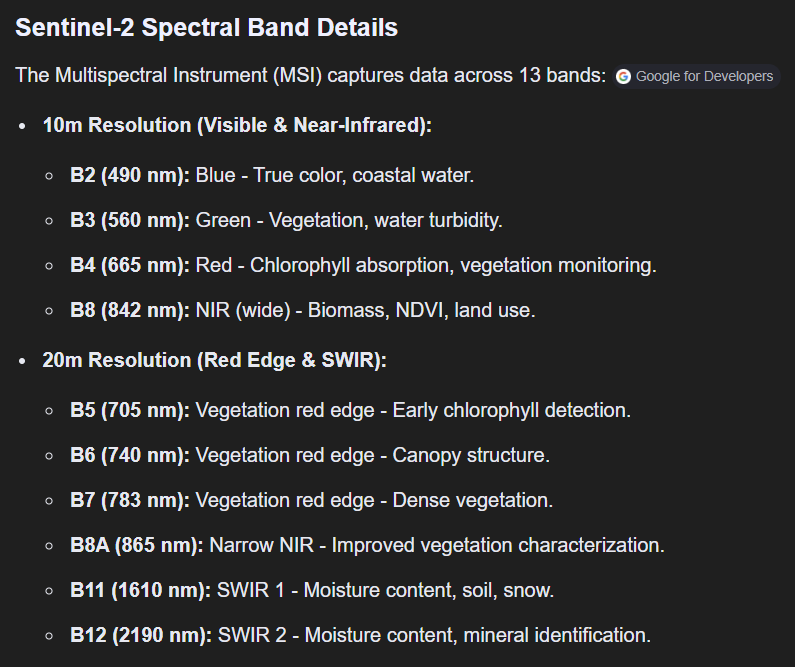
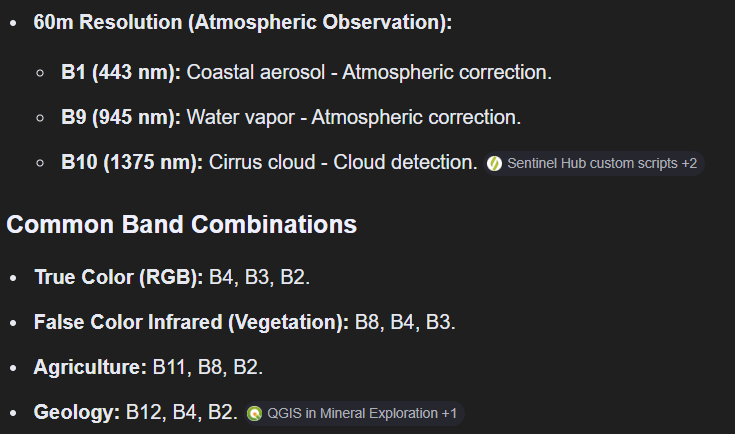

In [15]:
# Cell 6: Calculate and Display NDVI from Sentinel-2 (independent map)
#NDVI is Normalized Difference vegetation Index (uss NIR(Near Infrared)and red to estimate vegetation health/density)
#NDVI (towards 1 : dense,healhty ; towards 0 : bare soil/m=urban mix ; negative : water,snow,cloud etc..)

# Calculate NDVI = (NIR - Red) / (NIR + Red)(does this for each pixel)
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI') #B8 is Near Infrared(NIR) , B4 is red

# Visualization parameters for NDVI
ndvi_vis = {'min': -0.2, 'max': 0.8, 'palette': ['blue', 'white', 'green', 'darkgreen']}
# low NDVI (near -0.2) -> blue
# around middle values -> white
# higher NDVI -> green
# highest NDVI (near 0.8) -> darkgreen

# Use a separate map so Cell 5 split-slider remains unchanged
Map_ndvi = geemap.Map(center=center, zoom=11)
Map_ndvi.addLayer(s2, vis_s2, 'Sentinel-2 (Optical)', opacity=0.85) #s2 is the image data and vis_s2 is the visualization setting which contains diff bands(b4,B3,B2), mix , max)
Map_ndvi.addLayer(s1, vis_s1, 'Sentinel-1 (SAR)', opacity=0.55)
Map_ndvi.addLayer(ndvi, ndvi_vis, 'NDVI (Vegetation & Water)', opacity=0.65)
Map_ndvi.addLayerControl()

Map_ndvi

Map(center=[30.475, 79.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [16]:
# Calculate pixel count before export
area_sq_meters = aoi.area().getInfo()  # Get area in square meters
resolution = 10  # meters per pixel
estimated_pixels = area_sq_meters / (resolution ** 2)

print(f"AOI Area: {area_sq_meters / 1e6:.2f} km²")
print(f"Estimated pixels: {estimated_pixels:.0f}")
print(f"Estimated pixels in millions: {estimated_pixels / 1e6:.2f}")
print(f"Safe for export: {estimated_pixels < 1e13}")

AOI Area: 799.22 km²
Estimated pixels: 7992157
Estimated pixels in millions: 7.99
Safe for export: True


<mark>#### AOI BOUNDS CALCULATION - Uttarakhand(Joshimath)</mark>

- Uttarakhand coordinates : [79.35, 30.35, 79.65, 30.60]
- Longitude range: 79.65 - 79.35 = 0.30°
- Latitude range: 30.60 - 30.35 = 0.25°
- Center latitude: (30.35 + 30.60) / 2 = 30.475°

<b>Convert degrees → km (approximate)</b>

- 1° latitude ≈ 111.32 km (nearly constant)
- Latitude span in km: 0.25 * 111.32 ≈ 27.83 km
- 1° longitude ≈ 111.32 * cos(center_lat) km
- cos(30.475°) ≈ 0.862
- 1° longitude ≈ 111.32 * 0.862 ≈ 95.96 km
- Longitude span in km: 0.30 * 95.96 ≈ 28.79 km

<b>Area (rough rectangular approximation)</b> <br>

- Area ≈ longitude_km * latitude_km
- Area ≈ 28.79 km * 27.83 km ≈ 799 km² (rounded)
- Area in m²: 799 km² * 1e6 = 7.99 × 10^8 m² (≈ 799,000,000 m²)

<br>Pixel count at 10 m resolution<br>

- One 10 m pixel covers 10 m × 10 m = 100 m²
- Pixels ≈ area_m² / 100
- Pixels ≈ 7.99 × 10^8 / 100 ≈ 7,992,157 pixels (≈ 7.99 million)

Note : COPERNICUS/S2_SR_HARMONIZED had 11 bands instead of 13 bands (the full s2 dataset) , the B1(coastal Aerosol) and B10(Cirrus) are removed because they are for the atmospheric correction, SR is a processsed product(clouds/atmosphere corrected) , we are using 11 bands for a cleaner analysis.

In [17]:
# Estimate file size before export
print("=== ESTIMATED FILE SIZES ===")

# Sentinel-2: typically 11 bands, 16-bit unsigned int (2 bytes per band)
s2_bands = 11  # COPERNICUS/S2_SR_HARMONIZED has 11 bands #SR is surface reflectance has 11 bands like B2(blue) , B3(green) , B4(red) etc.
s2_bytes_per_pixel = 2  # 16-bit = 2 bytes
s2_file_size_mb = (estimated_pixels * s2_bands * s2_bytes_per_pixel) / (1024 ** 2)
#estimated_pixels = area_sq_meters / (resolution ** 2) (in prev cell)

# Sentinel-1: 2 bands (VV, VH), 32-bit float (4 bytes per band)
s1_bands = 2  # VV and VH
s1_bytes_per_pixel = 4  # 32-bit float = 4 bytes
s1_file_size_mb = (estimated_pixels * s1_bands * s1_bytes_per_pixel) / (1024 ** 2)

total_mb = s2_file_size_mb + s1_file_size_mb

print(f"Sentinel-2 (11 bands, 16-bit): {s2_file_size_mb:.2f} MB")
print(f"Sentinel-1 (2 bands, 32-bit): {s1_file_size_mb:.2f} MB")
print(f"Total estimate: {total_mb:.2f} MB ({total_mb / 1024:.2f} GB)")
print(f"Safe to export: {total_mb < 5000}")  # e.g., warn if > 5 GB

=== ESTIMATED FILE SIZES ===
Sentinel-2 (11 bands, 16-bit): 167.68 MB
Sentinel-1 (2 bands, 32-bit): 60.98 MB
Total estimate: 228.66 MB (0.22 GB)
Safe to export: True


In [ ]:
# Cell 7: Export Sentinel-2 and Sentinel-1 as GeoTIFF files using cloud (EE servers)
# (Tagged Image File Format) - TIFF + metadata = GEOTIFF
import os
from pathlib import Path

project_root = Path(r"D:\DrishtiSAR")
raw_dir = project_root / "data" / "raw" / "Uttarakhand_Joshimath"

# Create data folder if not exists (local cache, not used by Drive export)
os.makedirs(raw_dir, exist_ok=True)

# Use the selected_area variable (e.g., 'Uttarakhand_Joshimath') for task names
safe_name = selected_area.replace(' ', '_')
date_str = ''  # optional: add timestamp if desired

# Sentinel-2: Select ONLY spectral bands and convert to float (avoids type conflicts)
s2_rgb = s2.select(['B4', 'B3', 'B2']).float()  # RGB for visual
s2_nir = s2.select(['B8', 'B5', 'B6']).float()  # NIR, Red Edge, SWIR
s2_export = s2.select(['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']).float()

# Sentinel-1: 
s1_export = s1.select(['VV', 'VH']).float()

# Export Sentinel-2 (Optical) clipped to AOI
task_s2 = ee.batch.Export.image.toDrive(
    image=s2_export.clip(aoi),
    description=f'sentinel2_{safe_name}{date_str}',
    folder='DrishtiSAR/Uttarakhand_Joshimath',
    scale=10,  # Export resolution: 10 m per pixel
    region=aoi,
    fileFormat='GeoTIFF',
    maxPixels=1e10
)

# Export Sentinel-1 (SAR) clipped to AOI
task_s1 = ee.batch.Export.image.toDrive(
    image=s1_export.clip(aoi),
    description=f'sentinel1_{safe_name}{date_str}',
    folder='DrishtiSAR/Uttarakhand_Joshimath',
    scale=10,
    region=aoi,
    fileFormat='GeoTIFF',
    maxPixels=1e10
)

# Start tasks
task_s2.start()
task_s1.start()

print(f"Export tasks started for {selected_area}! Check your Google Drive 'Earth Engine' folder.")
print(f"Files will be: sentinel2_{safe_name}.tif and sentinel1_{safe_name}.tif")

Export tasks started for Uttarakhand_Joshimath! Check your Google Drive 'Earth Engine' folder.
Files will be: sentinel2_Uttarakhand_Joshimath.tif and sentinel1_Uttarakhand_Joshimath.tif
